<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">סיכום והצגת תוצאות ביניים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">על מנת שנוכל לבחון את טיב הפתרון שמסתמך על OCR + REGEX נחשב עבורו את המדדים הנפוצים בתחום מדעי הנתונים כמו דיוק ,F1 ועוד</div>
</div>

In [ ]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">תוצאות השלבים הקודמים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כדי לחשב את המדדים הנדרשים                           נשתמש בתוצאות השלב הקודם טבלת התוצאות(passport_detection_results.csv) מכילה לכל תמונת קלט את הREGEX שנתפס עבורה ואת אחת משלות התוצאות הסופיות האפשריות עבור זיהוי הדרכון. בנוסף יצרנו ידנית טבלת תיוגים(passport_page_labels.csv)                                                                                              שמציינת לכל מסמך את העמוד שבו נמצא אצלו תצלום הדרכון ואת רמת הקושי שלו.</div>
</div>

In [1]:
RESULTS_FILE = "./passport_detection_results.csv"
LABELS_FILE = "./passport_page_labels.csv"

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">מיזוג והתאמת התוצאות לתצוגה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כדני שנוכל להשוות בין הגישה                            המחמירה יותר שכוללת רק תוצאות YES לבין המחמירה פחות שכוללת גם את הדפים                                     שכיבלו MAYBE נמזג את שתי הטבלאות ונוסיף עמודות מתאימות כדי                                              שנוכל להציג את שני המיקרים.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">העמודות שהוספנו</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">prediction_strict - עבור העמודים שבוודאות מכילים דרכון(YES)

prediction_permissive - עבור כלל העמודים שישסיכוי שזוהה בהם דרכון(YES+MAYBE)</div>
</div>

In [2]:
results_df = pd.read_csv(RESULTS_FILE, encoding="utf-8-sig")
labels_df = pd.read_csv(LABELS_FILE, encoding="utf-8-sig")

page_data_df = results_df["image_name"].str.extract(
    r"^(?P<document_id>.+)_page_(?P<page_number>\d+)\.(?:jpg|jpeg|png)$",
    flags=re.IGNORECASE,
)

page_data_df["page_number"] = page_data_df["page_number"].astype(int)

evaluation_df = pd.concat(
    [results_df, page_data_df],
    axis=1,
).merge(
    labels_df[["document_id", "passport_page_number"]],
    on="document_id",
)

evaluation_df["is_passport"] = (
    evaluation_df["page_number"]
    == evaluation_df["passport_page_number"]
).astype(int)

evaluation_df["prediction_strict"] = (
    evaluation_df["verdict"] == "YES"
).astype(int)

evaluation_df["prediction_permissive"] = (
    evaluation_df["verdict"].isin(["YES", "MAYBE"])
).astype(int)

evaluation_df.head()

,image_name,matched_pattern_names,verdict,document_id,page_number,passport_page_number,is_passport,prediction_strict,prediction_permissive
0,PDF_Edge_Case_11_page_1.jpg,NaN,NO,PDF_Edge_Case_11,1,1,1,0,0
1,PDF_Edge_Case_12_page_1.jpg,NaN,NO,PDF_Edge_Case_12,1,3,0,0,0
2,PDF_Edge_Case_12_page_2.jpg,NaN,NO,PDF_Edge_Case_12,2,3,0,0,0
3,PDF_Edge_Case_12_page_3.jpg,NaN,NO,PDF_Edge_Case_12,3,3,1,0,0
4,PDF_Edge_Case_12_page_4.jpg,NaN,NO,PDF_Edge_Case_12,4,3,0,0,0


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">חישוב מדדים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">המדדים Accuracy, Precision, Recall ו־F1 נבחרו כדי להעריך את הגישה הראשונית שבה בחרנו מכמה היבטים משלימים: Accuracy מודד את שיעור העמודים שסווגו נכון מתוך כלל העמודים, Precision בודק כמה מהעמודים שסומנו כדרכון הם באמת עמודי דרכון, Recall מודד כמה מעמודי הדרכון האמיתיים המערכת הצליחה לזהות, ו־F1 מספק מדד מאוזן המשלב בין Precision ל־Recall מדד זה יהיה גבוה כאשר נזהה גם חלק גדול מהעמודים שמכילים דרכון וגם נמנע מזיהוי שגוי של עמודים שאינם מכילים דרכון.  השימוש בכל ארבעת המדדים חשוב במיוחד משום שמספר העמודים הרגילים גדול ממספר עמודי הדרכון, ולכן הסתמכות על Accuracy בלבד עלולה להציג תמונה מטעה.</div>
</div>

In [3]:
def calculate_metrics(prediction_column, approach):
    y_true = evaluation_df["is_passport"]
    y_pred = evaluation_df[prediction_column]

    return {
        "approach": approach,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


metrics_df = pd.DataFrame([
    calculate_metrics("prediction_strict", "YES only"),
    calculate_metrics("prediction_permissive", "YES + MAYBE"),
])

metrics_df

,approach,accuracy,precision,recall,f1
0,YES only,0.794326,1.000000,0.064516,0.121212
1,YES + MAYBE,0.843972,0.846154,0.354839,0.500000


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">יצוג התפלגות הזיהויים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">בחרנו להשתמש במטריצת בילבול על מנת להציג את כמות ההצלחה בזיהוי הן דפים שמכילים דרכון והן דפים שאינם מכילים אותו, נציין שלא הוספנו נתוני טקסט שיכולים לגרום לזיהוי                                                                                                           שגוי                                                                                                             כמו מחרוזות עם המילה PASSPORT וכו על מנת שנוכל לקבל תחושה עד כמה בכלל אפשר לסמוך על שיטת הזיהוי שאיתה התחלנו.                                                                               </div>
</div>

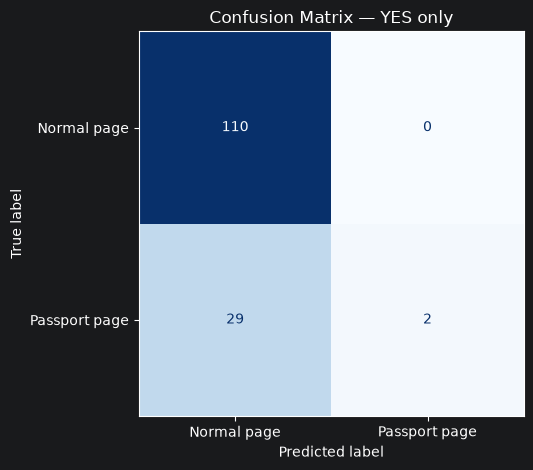

In [5]:
matrix = confusion_matrix(
    evaluation_df["is_passport"],
    evaluation_df["prediction_strict"],
)

ConfusionMatrixDisplay(
    matrix,
    display_labels=["Normal page", "Passport page"],
).plot(cmap="Blues", colorbar=False)

plt.title("Confusion Matrix — YES only")
plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">ניתוח תוצאות</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">ניתן     להבחין שבודאות זהינו רק 2 מתוך 31 עמודים שמכילים דרכונים , אך בנוסף נבחין שלא היו עמודים שאינם מכילים                                                                                                          דרכונים שסווגו לא נכון מה שמצביע על כך שה OCR ככל הנראה לא מדמיין טקסט ומסוגל לזהות תוכן בצורה טובה כשה הוא ירוץ                                                                 בגרסה כבדה יותר מזו שבחרנו</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">השוואה בין גישה מחמירה למתירנית</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כדי להבין לעומק את הפער בין שתי הגישות ביצענו השוואה                                                     גרפית בין המדדים שחישבנו קודם עבור שתיהן.</div>
</div>

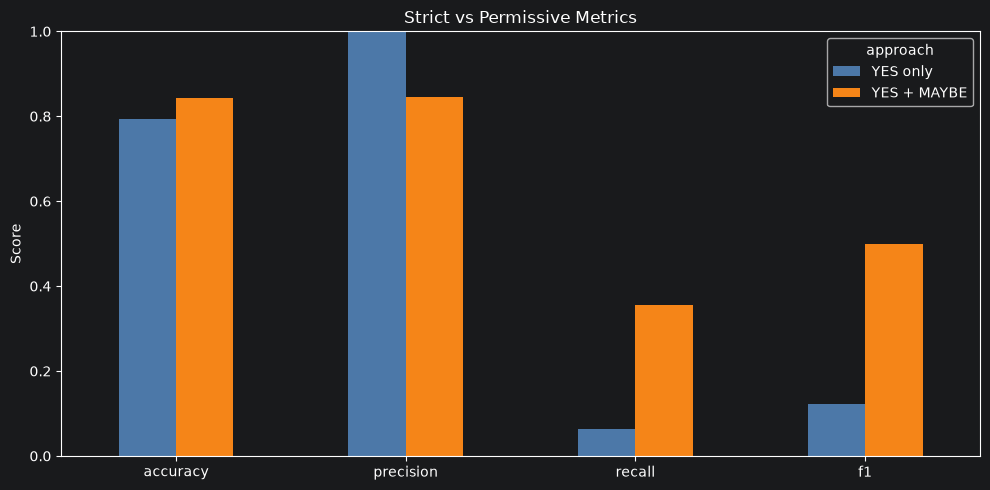

In [6]:
metrics_df.set_index("approach")[[
    "accuracy",
    "precision",
    "recall",
    "f1",
]].T.plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    color=["#4C78A8", "#F58518"],
)

plt.title("Strict vs Permissive Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">ניתוח תוצאות</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">
תוצאות ההשוואה מראות כי הגישה המחמירה משיגה Precision מושלם של 100%, אך Recall נמוך מאוד, ולכן מפספסת כמעט את כל עמודי הדרכון.  לאומת זאת בגישה הכללת תוצאות MAYBE נבחין ששיפרנו את ה־Recall לכמאט 40% ואת ה־F1 אף מעבר לכך, תוך שמירה על Precision גבוה של מעל 80%. עם זאת, גם בגישה זו 20 מתוך 31 עמודי דרכון לא זוהו. לכן המערכת יעילה בזיהוי חיובי מדויק כאשר קיימת התאמה ברורה, אך אינה רגישה מספיק, לכן בהמשך הפרוייקט נתרכז בלשלב מודל זיהוי חזותי נוסף במקום ה REGEX+OCR שכן גם אם ה OCR מחלץ את הנתונים טוב אז REGEX מתירני מידי יגרום להרבה טעויות בזיוי כאשר יש טקסט אקראי שיכול להופיע ולהכיל את המחרוזות טקסט הדומות לאלו שאנו מחפשים.
</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px;">
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">רקע לשלב הבא: גישה מבוססת למידה – רשת עצבית קונבולוציונית (CNN)</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">מהשלב הראשון עולה שהגישה הקיימת נתונה בין שני קצוות: תבניות מחמירות מפספסות את רוב עמודי הדרכון, ותבניות מתירניות עלולות להיתפס לטקסט אקראי המכיל מחרוזות דומות. שני הקצוות נובעים מאותו מקור  הזיהוי מסתמך על טקסט בלבד, ולטקסט אין הקשר מרחבי. כדי להתגבר על מגבלה זו, השלב הבא בפרויקט יתמקד ביישום מודל למידה עמוקה.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">רשת עצבית קונבולוציונית פועלת אחרת. היא מזהה תבניות חזותיות מקומיות בתמונה  קצוות, מרקמים ואזורים בעלי מבנה אופייני  ומצרפת אותן לייצוג של התמונה כולה. המאפיינים הללו נלמדים מדוגמאות מתויגות ואינם מוגדרים מראש ככללים. בהקשר שלנו, הרשת נדרשת ללמוד כיצד נראה תצלום דרכון בתוך מסמך, ולא לקרוא את הטקסט שבו  ולכן טקסט אקראי הדומה למחרוזת שאנו מחפשים אינו מטעה אותה.</div>

<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px; margin-bottom: 12px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">הרחבת מאגר הנתונים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מכיוון שאימון מודלים של למידה עמוקה מצריך כמות גדולה משמעותית של נתונים ביחס לגישה הנוכחית, השלב הבא יכלול הרחבה ניכרת של המאגר הקיים. נייצר ונוסיף מסמכים מגוונים נוספים, על מנת לספק לרשת מספיק דוגמאות ללמידה ולהימנע ממצב של התאמת-יתר (Overfitting).</div>
</div>

<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px; margin-bottom: 12px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">התאמת הקלט המתוכננת</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">התמונות יומרו ל-RGB וישנו גודל תוך שמירה על יחס הגובה-רוחב, ולאחר מכן יתווספו להן שוליים עד לגודל אחיד של 512×512  כאשר בהמשך תיבחן גם רזולוציה של 768×768. לבסוף, יבוצע נרמול בהתאם למודל המאומן מראש.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px; margin-bottom: 12px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">העשרת נתונים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">בזמן האימון בלבד יוחלו על התמונות מניפולציות כגון סיבוב, שינוי תאורה, טשטוש קל ושינוי פרספקטיבה. בקבוצות הוולידציה והמבחן יבוצעו שינוי גודל, הוספת שוליים ונרמול בלבד, כדי שההערכה תשקף בצורה נאמנה את הביצועים על נתונים גולמיים שלא עברו עיבוד נוסף.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">תוכנית אימון והערכה</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">יבוצעו מספר אימונים בתצורות שונות, ותוצאותיהם יושוו זו לזו. על בסיס תוצאות הביניים תשופר התצורה הנבחרת ותאומן מחדש, ולבסוף המודל ייבחן על נתוני מבחן (Test Set) שלא השתתפו בתהליך האימון.</div>
</div>
</div>